<a href="https://colab.research.google.com/github/DhanshreeRaut/Machine-Vision--CM59/blob/main/Practical_3_cm23059.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install OpenCV
!pip install opencv-python-headless -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

Saving BAG.jpg to BAG.jpg


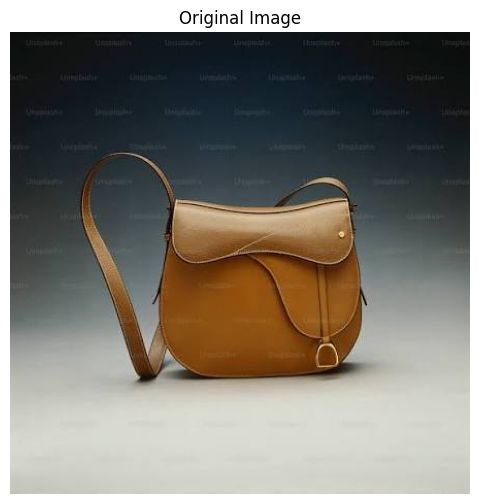

In [9]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Read image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

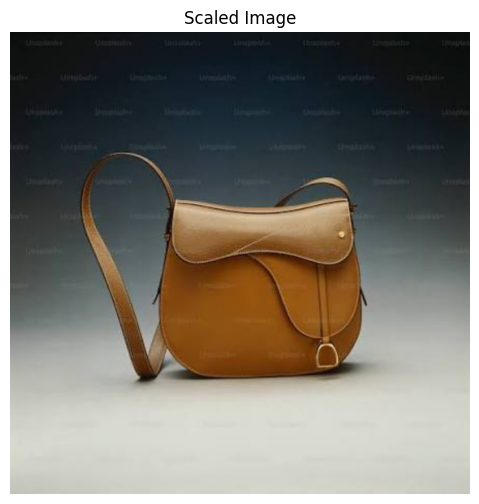

In [10]:
# ==========================================
# 1. Scaling
# ==========================================

scale_factor = 1.5

scaled = cv2.resize(image, None,
                    fx=scale_factor,
                    fy=scale_factor,
                    interpolation=cv2.INTER_LINEAR)

plt.figure(figsize=(6,6))
plt.imshow(scaled)
plt.title("Scaled Image")
plt.axis("off")
plt.show()


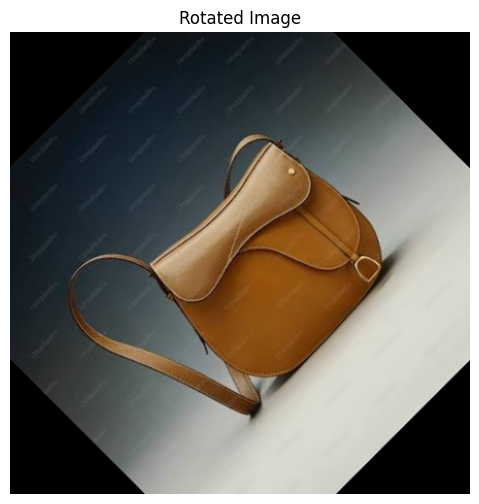

In [11]:
# ==========================================
# 2. Rotation
# ==========================================

(h, w) = image.shape[:2]
center = (w//2, h//2)

angle = 45

rotation_matrix = cv2.getRotationMatrix2D(center,
                                          angle,
                                          1.0)

rotated = cv2.warpAffine(image,
                         rotation_matrix,
                         (w, h))

plt.figure(figsize=(6,6))
plt.imshow(rotated)
plt.title("Rotated Image")
plt.axis("off")
plt.show()


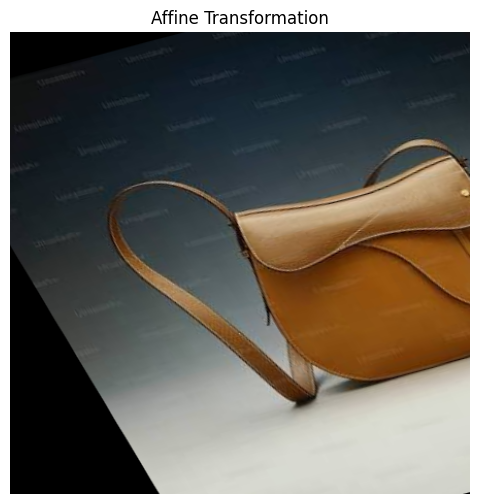

In [12]:

# ==========================================
# 3. Affine Transformation
# ==========================================

rows, cols = image.shape[:2]

pts1 = np.float32([[50,50],
                   [200,50],
                   [50,200]])

pts2 = np.float32([[10,100],
                   [200,50],
                   [100,250]])

affine_matrix = cv2.getAffineTransform(pts1, pts2)

affine = cv2.warpAffine(image,
                        affine_matrix,
                        (cols, rows))

plt.figure(figsize=(6,6))
plt.imshow(affine)
plt.title("Affine Transformation")
plt.axis("off")
plt.show()

Estimated Object Dimensions
----------------------------
Width : 446 pixels
Height: 341 pixels


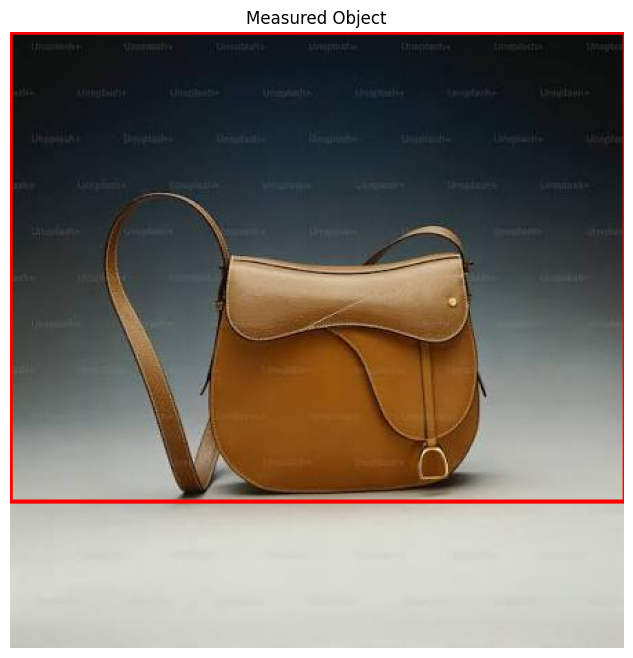

In [14]:
# ==========================================
# 4. Pixel-based Object Measurement
# ==========================================

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0)

_, thresh = cv2.threshold(blur,
                          120,
                          255,
                          cv2.THRESH_BINARY_INV)

# Find contours
contours, _ = cv2.findContours(thresh,
                               cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

output = image.copy()

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area > 1000:

        x, y, w, h = cv2.boundingRect(cnt)

        cv2.rectangle(output,
                      (x,y),
                      (x+w,y+h),
                      (255,0,0),
                      2)

        cv2.putText(output,
                    f"W:{w}px",
                    (x, y-25),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255,0,0),
                    2)

        cv2.putText(output,
                    f"H:{h}px",
                    (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255,0,0),
                    2)

        print("Estimated Object Dimensions")
        print("----------------------------")
        print("Width :", w, "pixels")
        print("Height:", h, "pixels")

plt.figure(figsize=(8,8))
plt.imshow(output)
plt.title("Measured Object")
plt.axis("off")
plt.show()